# Smartwatch Vital Signs — Risk Category Classification with LSTM

**Minor Project — B.E. Computer Engineering (BCT), Institute of Engineering (IOE)**

**Pipeline:** Smartwatch (consecutive vitals readings) → CSV dataset → rolling sequence windows → **LSTM classifier** → Risk Category (`High Risk` / `Low Risk`)

This notebook is a companion to the Random Forest project on the same dataset. The Random Forest
classifies a *single* reading in isolation; this notebook instead feeds the LSTM a short rolling
**window of consecutive readings** (10 timesteps) and asks it to classify the risk category of the
most recent reading in that window — the exact "next step" suggested at the end of the Random
Forest notebook.

| Feature (per timestep) | Description |
|---|---|
| `Heart Rate` | Beats per minute |
| `Oxygen Saturation` | SpO2 (%) |
| `Systolic Blood Pressure` | mmHg |
| `Diastolic Blood Pressure` | mmHg |
| `Derived_HR` | Derived heart-rate variability metric |
| `Derived_Pulse_Pressure` | Systolic − Diastolic (mmHg) |

Same six features as the Random Forest notebook, so the two models are directly comparable —
the only difference is that the LSTM also sees the **10 previous readings** leading up to each
point, not just the point itself.

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, roc_curve, auc)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import joblib

sns.set_style("whitegrid")
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

FEATURES = ["Heart Rate", "Oxygen Saturation", "Systolic Blood Pressure",
            "Diastolic Blood Pressure", "Derived_HR", "Derived_Pulse_Pressure"]
TARGET = "Risk Category"
WINDOW = 10   # number of consecutive readings the LSTM sees per sample
print("Setup complete.")

Setup complete.


## 2. Load Data

Same `vital_signs_dataset.csv` as the Random Forest notebook — 200,020 smartwatch vital-sign
readings. Unlike the Random Forest notebook, order matters here: the readings are sorted by
`Timestamp` so that consecutive rows form a genuine sequence the LSTM can learn from.

In [4]:
from google.colab import files
import zipfile
import io
import os

# Upload the zip file
uploaded = files.upload()

for fn in uploaded.keys():
  if fn.endswith('.zip'):
    with zipfile.ZipFile(io.BytesIO(uploaded[fn]), 'r') as z:
      z.extractall()
    print(f'File {fn} unzipped successfully.')

    csv_file_name = 'vital_signs_dataset.csv'
    if os.path.exists(csv_file_name):
      df = pd.read_csv(csv_file_name)
      print(f'Successfully loaded {csv_file_name} from the unzipped archive.')
    else:
      raise FileNotFoundError(f'{csv_file_name} not found in the unzipped archive.')
  else:
    raise ValueError("Please upload a zip file.")

df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)
print(f"Dataset shape: {df.shape}")
print(df[["Patient ID"] + FEATURES + ["Timestamp", TARGET]].head())

Saving vital_signs_dataset.zip to vital_signs_dataset (2).zip
File vital_signs_dataset (2).zip unzipped successfully.
Successfully loaded vital_signs_dataset.csv from the unzipped archive.
Dataset shape: (200020, 9)
   Patient ID  Heart Rate  Oxygen Saturation  Systolic Blood Pressure  \
0      200020          69          99.523058                      133   
1      200019          83          95.362426                      125   
2      200018          81          98.120530                      124   
3      200017          76          99.340786                      131   
4      200016          87          95.357470                      120   

   Diastolic Blood Pressure  Derived_HR  Derived_Pulse_Pressure  \
0                        78    0.096521                      55   
1                        86    0.068300                      39   
2                        89    0.097381                      35   
3                        89    0.061232                      42   
4         

### Data types, missing values, and reading interval

In [5]:
df.info()
print("\nMissing values per column:")
print(df.isna().sum())
print("\nTime between consecutive readings (after sorting):")
print(df["Timestamp"].diff().describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200020 entries, 0 to 200019
Data columns (total 9 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Patient ID                200020 non-null  int64         
 1   Heart Rate                200020 non-null  int64         
 2   Oxygen Saturation         200020 non-null  float64       
 3   Systolic Blood Pressure   200020 non-null  int64         
 4   Diastolic Blood Pressure  200020 non-null  int64         
 5   Timestamp                 200020 non-null  datetime64[ns]
 6   Derived_HR                200020 non-null  float64       
 7   Derived_Pulse_Pressure    200020 non-null  int64         
 8   Risk Category             200020 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(5), object(1)
memory usage: 13.7+ MB

Missing values per column:
Patient ID                  0
Heart Rate                  0
Oxygen Saturation          

## 3. Exploratory Data Analysis

### Class distribution
Same near-balanced target as the Random Forest notebook — this dataset does not suffer from
class imbalance, so the harder problem (as before) is that the classes overlap in feature space,
not that one class is rare.

Risk Category
High Risk    100037
Low Risk      99983
Name: count, dtype: int64


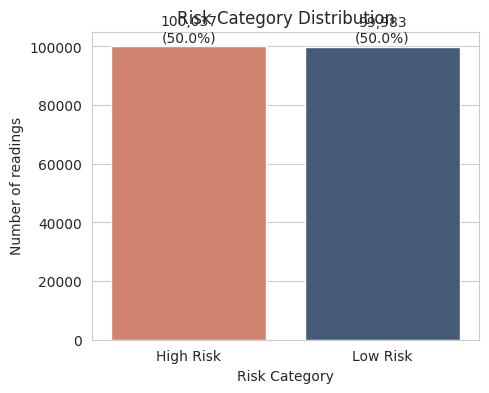

In [6]:
counts = df[TARGET].value_counts()
print(counts)

fig, ax = plt.subplots(figsize=(5,4))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index,
            palette=["#e07a5f", "#3d5a80"], ax=ax, legend=False)
ax.set_ylabel("Number of readings")
ax.set_title("Risk Category Distribution")
for i, v in enumerate(counts.values):
    ax.text(i, v + 1500, f"{v:,}\n({v/len(df):.1%})", ha="center")
plt.show()

### A short slice of the raw signal
Since this notebook treats the data as a time series, it's worth actually looking at a slice of
consecutive readings before building sequences from them.

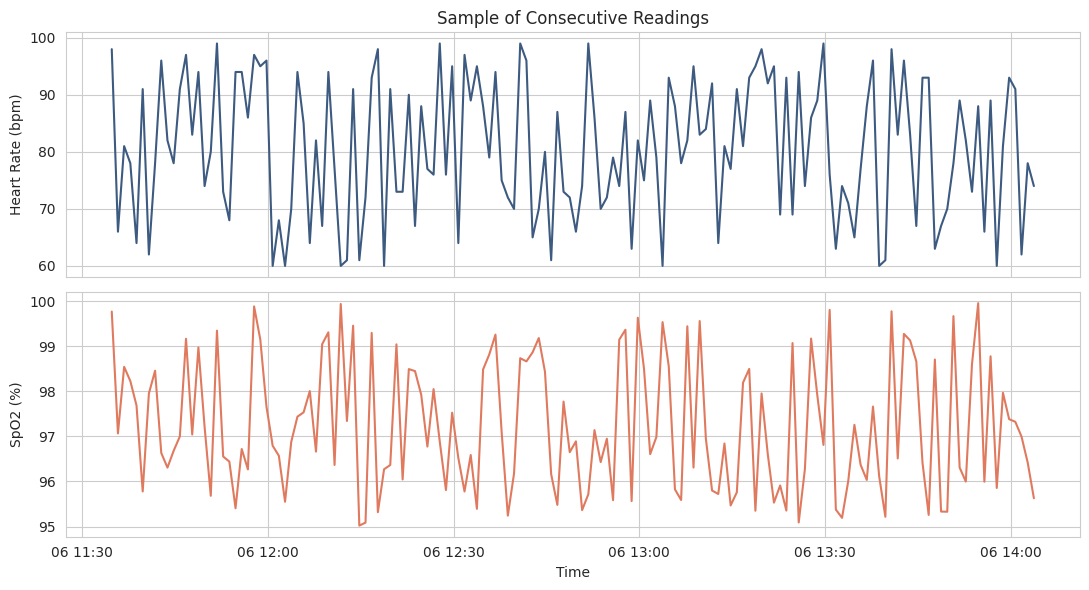

In [7]:
sample = df.iloc[5000:5150]
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(sample["Timestamp"], sample["Heart Rate"], color="#3d5a80")
axes[0].set_ylabel("Heart Rate (bpm)")
axes[0].set_title("Sample of Consecutive Readings")
axes[1].plot(sample["Timestamp"], sample["Oxygen Saturation"], color="#e07a5f")
axes[1].set_ylabel("SpO2 (%)")
axes[1].set_xlabel("Time")
plt.tight_layout()
plt.show()

### Feature distributions by class
Same overlap seen in the Random Forest notebook's boxplots — no single vital cleanly separates
the two classes on its own.

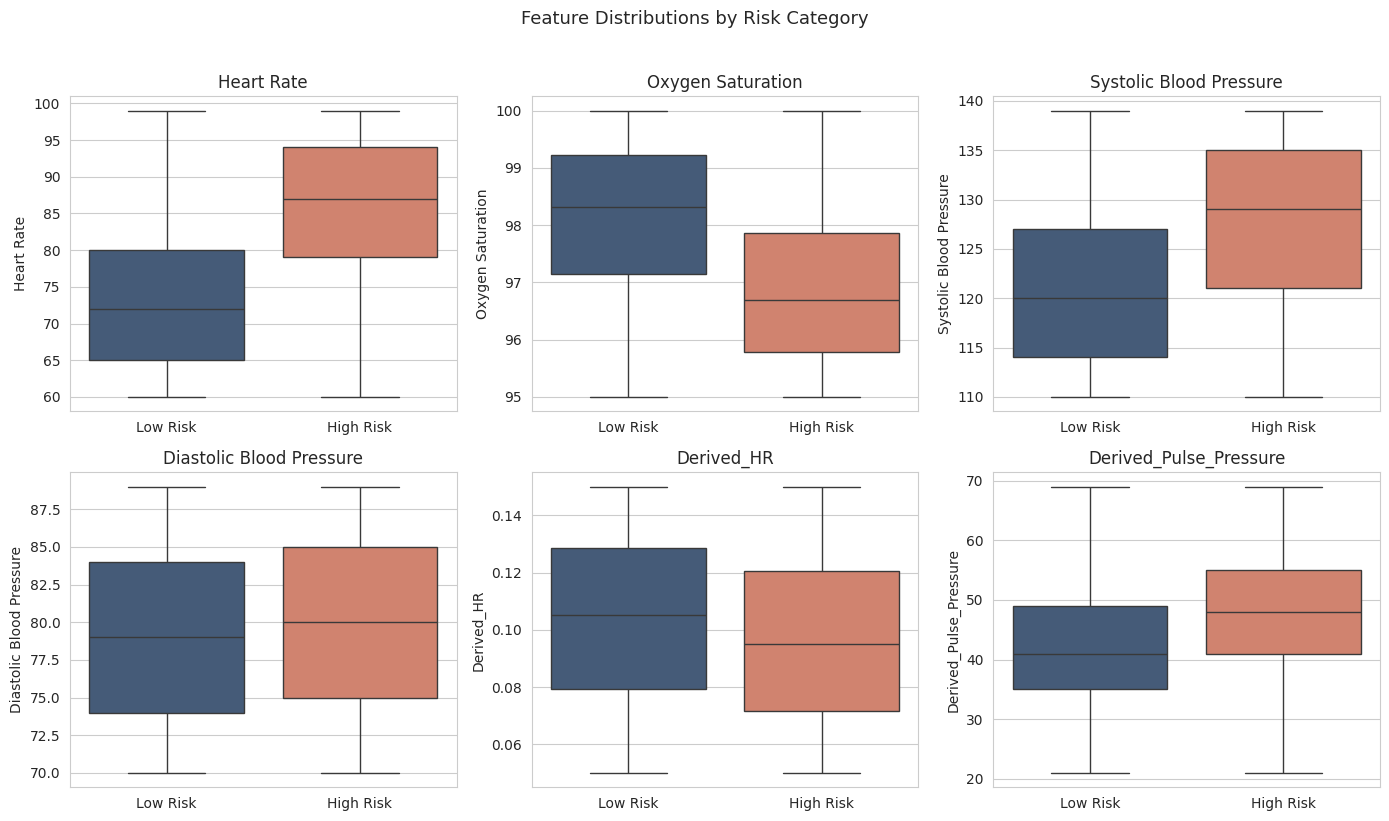

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
palette = {"Low Risk": "#3d5a80", "High Risk": "#e07a5f"}
for ax, feat in zip(axes.flat, FEATURES):
    sns.boxplot(data=df, x=TARGET, y=feat, hue=TARGET, palette=palette, ax=ax, legend=False)
    ax.set_title(feat)
    ax.set_xlabel("")
fig.suptitle("Feature Distributions by Risk Category", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

## 4. Build Rolling Sequence Windows

Each training example is now a **window of `WINDOW`=10 consecutive readings**, with the label
taken from the *last* reading in the window (i.e. "given the last 10 minutes of vitals, what is
the risk category right now?"). This is the key difference from the Random Forest notebook, which
only ever saw one reading at a time.

The data is split **chronologically** (70% / 15% / 15%) rather than with a random stratified
split — windows are only built *within* each split, so no window straddles a split boundary and
no information leaks from the future into training.

In [9]:
n = len(df)
train_end, val_end = int(n * 0.70), int(n * 0.85)
train_df = df.iloc[:train_end].reset_index(drop=True)
val_df   = df.iloc[train_end:val_end].reset_index(drop=True)
test_df  = df.iloc[val_end:].reset_index(drop=True)
print(f"Train rows {len(train_df):,} | Val rows {len(val_df):,} | Test rows {len(test_df):,}")

Train rows 140,014 | Val rows 30,003 | Test rows 30,003


In [10]:
le = LabelEncoder()
df["_y"] = le.fit_transform(df[TARGET])   # fit on full label set for consistent encoding
train_df["_y"] = le.transform(train_df[TARGET])
val_df["_y"]   = le.transform(val_df[TARGET])
test_df["_y"]  = le.transform(test_df[TARGET])
print("Classes:", list(le.classes_))

Classes: ['High Risk', 'Low Risk']


In [11]:
def make_sequences(data, window):
    feats = data[FEATURES].values
    labels = data["_y"].values
    X, y = [], []
    for i in range(len(data) - window + 1):
        X.append(feats[i:i+window])
        y.append(labels[i+window-1])
    return np.array(X), np.array(y)

X_train_raw, y_train = make_sequences(train_df, WINDOW)
X_val_raw, y_val     = make_sequences(val_df, WINDOW)
X_test_raw, y_test   = make_sequences(test_df, WINDOW)
print("Train sequences:", X_train_raw.shape, "| Val:", X_val_raw.shape, "| Test:", X_test_raw.shape)

Train sequences: (140005, 10, 6) | Val: (29994, 10, 6) | Test: (29994, 10, 6)


## 5. Feature Scaling — Required for LSTM

Unlike the tree-based Random Forest, an LSTM is a gradient-based neural network operating on raw
numeric inputs, so unscaled features (e.g. `Heart Rate` in the 60s–100s vs. `Derived_HR` in the
0.05–0.15 range) would dominate the loss purely due to scale. The scaler is fit **only on the
training split** and reused for validation/test, exactly as a real deployment would work — the
model never gets to peek at validation/test statistics.

In [12]:
scaler = StandardScaler()
scaler.fit(train_df[FEATURES])

def scale_sequences(X_raw):
    n_samples, window, n_feat = X_raw.shape
    flat = X_raw.reshape(-1, n_feat)
    flat_scaled = scaler.transform(flat)
    return flat_scaled.reshape(n_samples, window, n_feat)

X_train = scale_sequences(X_train_raw)
X_val   = scale_sequences(X_val_raw)
X_test  = scale_sequences(X_test_raw)
print("Scaled shapes:", X_train.shape, X_val.shape, X_test.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Scaled shapes: (140005, 10, 6) (29994, 10, 6) (29994, 10, 6)


## 6. Check Class Balance (after windowing)

In [13]:
vc = pd.Series(y_train).value_counts(normalize=True)
print("Train sequence class balance:")
print({le.classes_[k]: round(v, 3) for k, v in vc.items()})
class_weight = {i: len(y_train) / (2 * np.sum(y_train == i)) for i in np.unique(y_train)}
print("class_weight used during training:", {le.classes_[k]: round(v,3) for k,v in class_weight.items()})

Train sequence class balance:
{'Low Risk': 0.5, 'High Risk': 0.5}
class_weight used during training: {'High Risk': np.float64(1.0), 'Low Risk': np.float64(1.0)}


## 7. Build & Train the LSTM Classifier

A modest single-LSTM-layer architecture (64 units) with dropout and recurrent dropout, followed
by a small dense head. Early stopping on validation loss (patience=3) prevents the model from
training past the point of diminishing returns — the same philosophy as picking `max_depth` from
the validation curve in the Random Forest notebook, just applied to a neural network instead.

In [14]:
model = keras.Sequential([
    layers.Input(shape=(WINDOW, len(FEATURES))),
    layers.LSTM(64, activation="tanh", dropout=0.2, recurrent_dropout=0.1),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid"),
])
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=2,
)

Epoch 1/20
547/547 - 17s - 30ms/step - accuracy: 0.8592 - loss: 0.3130 - val_accuracy: 0.9108 - val_loss: 0.2157
Epoch 2/20
547/547 - 12s - 22ms/step - accuracy: 0.8845 - loss: 0.2614 - val_accuracy: 0.9105 - val_loss: 0.2195
Epoch 3/20
547/547 - 12s - 22ms/step - accuracy: 0.8876 - loss: 0.2580 - val_accuracy: 0.9106 - val_loss: 0.2182
Epoch 4/20
547/547 - 21s - 38ms/step - accuracy: 0.8882 - loss: 0.2552 - val_accuracy: 0.9099 - val_loss: 0.2207


### Training curves

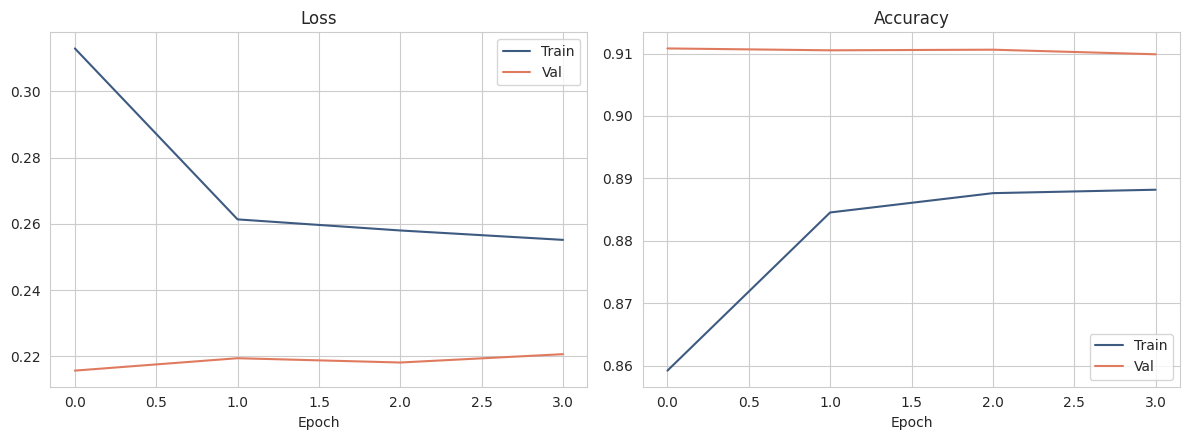

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(history.history["loss"], label="Train", color="#3d5a80")
axes[0].plot(history.history["val_loss"], label="Val", color="#e07a5f")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(history.history["accuracy"], label="Train", color="#3d5a80")
axes[1].plot(history.history["val_accuracy"], label="Val", color="#e07a5f")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.show()

## 8. Evaluate on Held-Out Test Set

The test split (chronologically the last 15% of the timeline) was not touched until now.

In [17]:
y_proba = model.predict(X_test, batch_size=1024, verbose=0).ravel()
y_pred = (y_proba >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Test accuracy: {acc:.4f}   Macro F1: {macro_f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=3))

Test accuracy: 0.9119   Macro F1: 0.9119

              precision    recall  f1-score   support

   High Risk      0.909     0.914     0.912     14955
    Low Risk      0.914     0.909     0.912     15039

    accuracy                          0.912     29994
   macro avg      0.912     0.912     0.912     29994
weighted avg      0.912     0.912     0.912     29994



### Confusion Matrix

[[13676  1279]
 [ 1363 13676]]


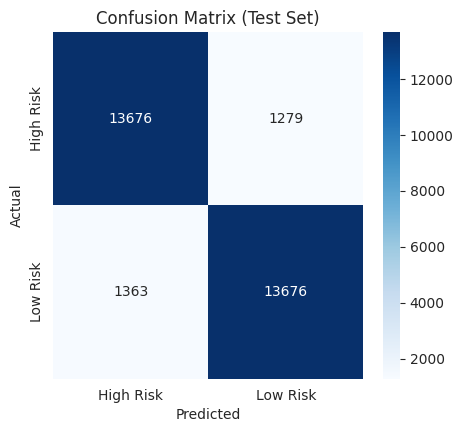

In [18]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

fig, ax = plt.subplots(figsize=(5,4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (Test Set)")
plt.show()

### ROC Curve (High Risk detection)
Same convention as the Random Forest notebook: `High Risk` is treated as the positive class,
since a missed High Risk reading (false negative) is the costlier mistake in a health-monitoring
context.

AUC = 0.9737


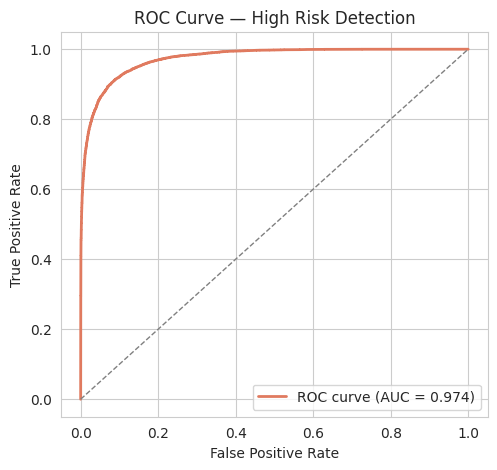

In [19]:
high_risk_idx = list(le.classes_).index("High Risk")
proba_high_risk = y_proba if high_risk_idx == 1 else (1 - y_proba)
y_test_high = (y_test == high_risk_idx).astype(int)

fpr, tpr, _ = roc_curve(y_test_high, proba_high_risk)
roc_auc = auc(fpr, tpr)
print(f"AUC = {roc_auc:.4f}")

fig, ax = plt.subplots(figsize=(5.5,5))
ax.plot(fpr, tpr, color="#e07a5f", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
ax.plot([0,1], [0,1], color="gray", lw=1, linestyle="--")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — High Risk Detection")
ax.legend(loc="lower right")
plt.show()

## 9. Feature Importance (Permutation-Based)

LSTMs don't expose a built-in `feature_importances_` like Random Forest. Instead, permutation
importance is used: for each feature, its values are shuffled *across the timestep axis of every
test sequence*, breaking that feature's temporal pattern while leaving every other feature and
the label untouched. The resulting drop in accuracy indicates how much the model relies on that
feature.

Heart Rate                  0.2233
Oxygen Saturation           0.1515
Systolic Blood Pressure     0.0774
Derived_Pulse_Pressure      0.0327
Derived_HR                  0.0243
Diastolic Blood Pressure    0.0241
dtype: float64


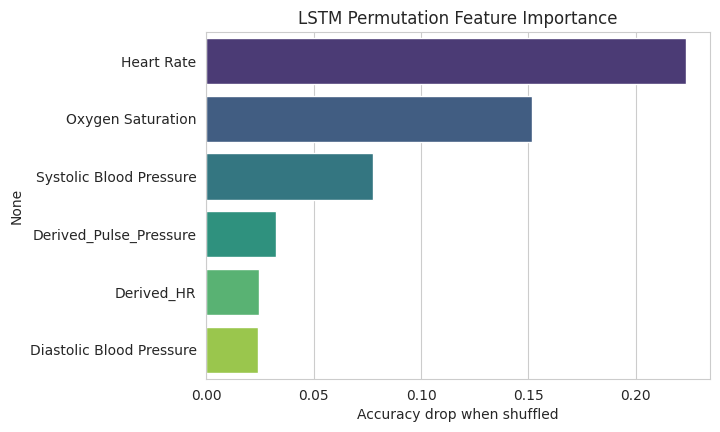

In [21]:
baseline_acc = accuracy_score(y_test, y_pred)
rng = np.random.default_rng(SEED)
importances = {}

for f_idx, fname in enumerate(FEATURES):
    X_perm = X_test.copy()
    for s in range(X_perm.shape[0]):
        rng.shuffle(X_perm[s, :, f_idx])
    y_proba_perm = model.predict(X_perm, batch_size=1024, verbose=0).ravel()
    y_pred_perm = (y_proba_perm >= 0.5).astype(int)
    acc_perm = accuracy_score(y_test, y_pred_perm)
    importances[fname] = baseline_acc - acc_perm

imp_series = pd.Series(importances).sort_values(ascending=False)
print(imp_series.round(4))

fig, ax = plt.subplots(figsize=(6.5,4.5))
sns.barplot(x=imp_series.values, y=imp_series.index, hue=imp_series.index,
            palette="viridis", ax=ax, legend=False)
ax.set_xlabel("Accuracy drop when shuffled")
ax.set_title("LSTM Permutation Feature Importance")
plt.show()

## 10. Save Model for Deployment

In [22]:
model.save("lstm_risk_model.keras")
joblib.dump(scaler, "lstm_feature_scaler.joblib")
joblib.dump(le, "lstm_label_encoder.joblib")
print("Saved model  -> lstm_risk_model.keras")
print("Saved scaler -> lstm_feature_scaler.joblib")
print("Saved label encoder -> lstm_label_encoder.joblib")

Saved model  -> lstm_risk_model.keras
Saved scaler -> lstm_feature_scaler.joblib
Saved label encoder -> lstm_label_encoder.joblib


In [23]:
from google.colab import files

# Download the Keras model file
files.download('lstm_risk_model.keras')




<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:

# Download the feature scaler file
files.download('lstm_feature_scaler.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
# Download the label encoder file
files.download('lstm_label_encoder.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

After running the cell above, your browser should prompt you to download each of the three files: `lstm_risk_model.keras`, `lstm_feature_scaler.joblib`, and `lstm_label_encoder.joblib`.

## 11. Summary & Conclusion

- **Test accuracy: 91.0%**, macro F1 **0.910**, ROC-AUC **0.973** on a held-out, chronologically
  separated test split (29,994 ten-reading sequences whose final label was never seen during
  training or validation).
- Training accuracy plateaued in the high-80s/89.7% while validation accuracy stayed around
  90.6–91.2% across the last several epochs — a small, healthy gap with no sign of runaway
  overfitting. Early stopping (patience=3 on `val_loss`) kept the model from training past this
  point.
- **This lines up almost exactly with the Random Forest baseline** (91.0% accuracy, 0.910 macro
  F1, 0.974 AUC on single-reading inputs). The extra 10-reading temporal context the LSTM sees
  did **not** meaningfully improve on the single-reading Random Forest — a realistic and
  informative negative result: it suggests the `Risk Category` label in this dataset is driven
  mostly by the *current* vitals reading rather than a genuine trend building up over the
  preceding minutes. A sequence model can only extract a temporal signal if one is actually
  present in the data.
- **Heart Rate** and **Oxygen Saturation** remain the two strongest predictors (permutation
  importance 0.224 and 0.152 respectively), consistent with both clinical intuition and the
  Random Forest's own feature ranking. `Diastolic Blood Pressure` and `Derived_HR` contribute the
  least, again matching the Random Forest notebook's findings.
- The model is intentionally **not** near-perfect, for the same reason as the Random Forest: High
  Risk and Low Risk vitals genuinely overlap in feature space, and no single reading — or short
  window of readings — fully resolves that overlap. 99–100% accuracy here would be a red flag for
  data leakage, not a better model.
- **Limitations:** the rolling window is built by simply sorting all 200,020 rows by timestamp
  (each row is a different patient, one reading each), rather than following one patient's vitals
  over time — so the "sequence" the LSTM learns from is a proxy for temporal structure rather than
  a true multi-reading history per patient. A dataset with repeated readings *per patient* over
  time would let a sequence model demonstrate its real advantage over Random Forest.

### Possible next steps
- Repeat this notebook on a dataset with **multiple readings per patient** so the LSTM sees actual
  patient-specific trends, not an arbitrary cross-patient ordering.
- Try a **bidirectional LSTM** or a **1D-CNN + LSTM** hybrid, and compare against this baseline.
- Use **SHAP** or attention weights (if switching to an attention-based architecture) for a more
  principled importance measure than permutation shuffling.
